# Эксперимент: BiLSTM-GRU на log-mel спектрограмме

**Модель:** BiLSTM → GRU → mean pooling → FC + SpecAugment  
**Группа:** 02_spectrogram_models

In [1]:
import sys
from pathlib import Path
import numpy as np
import time
from joblib import Parallel, delayed
import mlflow
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score as _f1
import matplotlib.pyplot as plt

exp_dir = Path().resolve()
sys.path.insert(0, str(exp_dir.parent.parent))
sys.path.insert(0, str(exp_dir))

from shared import config, data_utils, train_utils
from shared.evaluate import find_optimal_threshold, evaluate
from shared.results_utils import save_result_csv
from shared.mlflow_utils import start_run, log_epoch, log_artifact_if_exists
from model import get_model

train_utils.set_seed(config.RANDOM_STATE)

/Users/dk/miniconda3/envs/vkr/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
(
    paths_trainval, labels_trainval, letters_trainval,
    paths_test, labels_test, letters_test,
) = data_utils.get_holdout_split()

idx = np.arange(len(paths_trainval))
idx_tr, idx_val = train_test_split(
    idx, test_size=0.18, stratify=labels_trainval, random_state=config.RANDOM_STATE
)
paths_train,   paths_val   = paths_trainval[idx_tr],   paths_trainval[idx_val]
labels_train,  labels_val  = labels_trainval[idx_tr],  labels_trainval[idx_val]
letters_train, letters_val = letters_trainval[idx_tr], letters_trainval[idx_val]

In [3]:
N_MELS, N_FRAMES = config.N_MELS, 320

def load_mel(path):
    return data_utils.extract_mel_spectrogram(path, max_frames=N_FRAMES)

print("Mel...")
X_train = np.stack(Parallel(n_jobs=-1)(delayed(load_mel)(p) for p in paths_train))
X_val   = np.stack(Parallel(n_jobs=-1)(delayed(load_mel)(p) for p in paths_val))
X_test  = np.stack(Parallel(n_jobs=-1)(delayed(load_mel)(p) for p in paths_test))

mel_mean = X_train.mean(axis=(0, 2), keepdims=True)
mel_std  = np.where(X_train.std(axis=(0, 2), keepdims=True) < 1e-6, 1.0,
                    X_train.std(axis=(0, 2), keepdims=True))
X_train = (X_train - mel_mean) / mel_std
X_val   = (X_val   - mel_mean) / mel_std
X_test  = (X_test  - mel_mean) / mel_std
# (N, N_MELS, T) → (N, T, N_MELS) для LSTM
X_train = X_train.transpose(0, 2, 1)
X_val   = X_val.transpose(0, 2, 1)
X_test  = X_test.transpose(0, 2, 1)

Mel...


In [4]:
class MelSeqDataset(Dataset):
    def __init__(self, X, letters, labels, augment=False):
        self.X, self.letters, self.labels, self.augment = X, letters, labels, augment
    def __len__(self): return len(self.labels)
    def __getitem__(self, i):
        x = self.X[i].copy()
        if self.augment:
            x = data_utils.augment_mel_spectrogram(x.T).T
        return torch.from_numpy(x).float(), torch.from_numpy(self.letters[i]).float(), int(self.labels[i])

device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")
BATCH = 32
train_loader = DataLoader(MelSeqDataset(X_train, letters_train, labels_train, augment=True),  batch_size=BATCH, shuffle=True)
val_loader   = DataLoader(MelSeqDataset(X_val,   letters_val,   labels_val,   augment=False), batch_size=BATCH, shuffle=False)
test_loader  = DataLoader(MelSeqDataset(X_test,  letters_test,  labels_test,  augment=False), batch_size=BATCH, shuffle=False)

/Users/dk/miniconda3/envs/vkr/lib/python3.10/site-packages/mlflow/tracking/_tracking_service/utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)
2026/04/13 09:49:01 INFO mlflow.tracking.fluent: Experiment with name '02_spectrogram_models' does not exist. Creating a new experiment.


Epoch 1/60  loss=0.6530  val_f1=0.6571
Epoch 2/60  loss=0.6410  val_f1=0.6375
Epoch 3/60  loss=0.6203  val_f1=0.6804
Epoch 4/60  loss=0.6208  val_f1=0.6627
Epoch 5/60  loss=0.6241  val_f1=0.6652
Epoch 6/60  loss=0.6083  val_f1=0.6810
Epoch 7/60  loss=0.5988  val_f1=0.6565
Epoch 8/60  loss=0.5931  val_f1=0.6865
Epoch 9/60  loss=0.6026  val_f1=0.6870
Epoch 10/60  loss=0.5871  val_f1=0.7032
Epoch 11/60  loss=0.5860  val_f1=0.6985
Epoch 12/60  loss=0.5891  val_f1=0.7103
Epoch 13/60  loss=0.5796  val_f1=0.7220
Epoch 14/60  loss=0.5719  val_f1=0.7007
Epoch 15/60  loss=0.5770  val_f1=0.7118
Epoch 16/60  loss=0.5605  val_f1=0.7172
Epoch 17/60  loss=0.5754  val_f1=0.7266
Epoch 18/60  loss=0.5545  val_f1=0.7193
Epoch 19/60  loss=0.5514  val_f1=0.6722
Epoch 20/60  loss=0.5432  val_f1=0.7171
Epoch 21/60  loss=0.5394  val_f1=0.7170
Epoch 22/60  loss=0.5462  val_f1=0.7378
Epoch 23/60  loss=0.5379  val_f1=0.7258
Epoch 24/60  loss=0.5249  val_f1=0.6607
Epoch 25/60  loss=0.5247  val_f1=0.7131
Epoch 26/

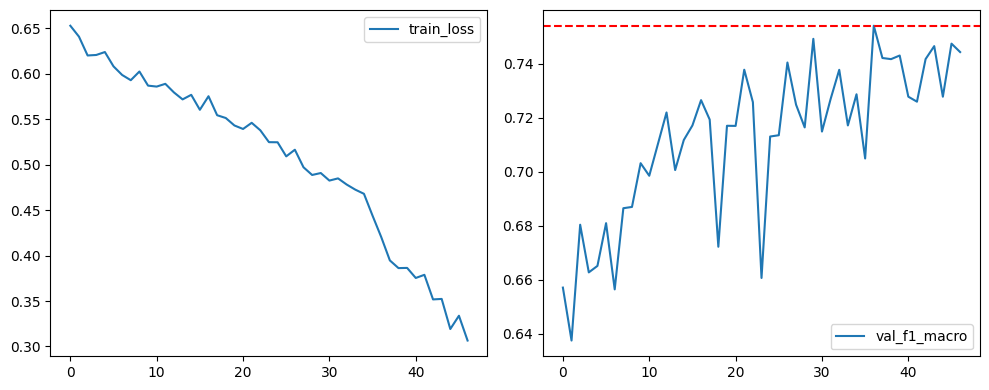

Результаты сохранены


In [5]:
n_letters = letters_train.shape[1]
N_EPOCHS, LSTM_H, GRU_H, DROPOUT = 60, 128, 64, 0.3

with start_run("exp_bilstm_gru", group="02_spectrogram_models"):

    mlflow.log_params({
        "model": "BiLSTM-GRU", "n_mels": N_MELS, "n_frames": N_FRAMES,
        "lstm_hidden": LSTM_H, "gru_hidden": GRU_H, "dropout": DROPOUT,
        "augment": "SpecAugment", "n_epochs": N_EPOCHS,
        "optimizer": "AdamW", "lr": 1e-3,
    })

    model = get_model(input_size=N_MELS, num_classes=2, lstm_hidden=LSTM_H,
                      gru_hidden=GRU_H, n_letters=n_letters, dropout=DROPOUT).to(device)
    n_params = sum(p.numel() for p in model.parameters())
    mlflow.log_param("num_params", n_params)

    weights = compute_class_weight("balanced", classes=np.unique(labels_train), y=labels_train)
    criterion = nn.CrossEntropyLoss(weight=torch.tensor(weights, dtype=torch.float32, device=device))
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = train_utils.get_lr_scheduler(optimizer)
    early_stopping = train_utils.EarlyStopping(patience=config.EARLY_STOPPING_PATIENCE)
    best_ckpt, best_f1 = exp_dir / "best_ckpt.pt", -1.0

    def eval_loader(loader):
        model.eval()
        logits_list, true_list = [], []
        with torch.no_grad():
            for x, letters, y in loader:
                logits_list.append(model(x.to(device), letters.to(device)).cpu().numpy())
                true_list.extend(y.tolist())
        logits = np.concatenate(logits_list)
        proba  = torch.softmax(torch.from_numpy(logits), dim=1).numpy()[:, config.CLASS_BAD]
        return proba, np.array(true_list)

    train_losses, val_f1s = [], []
    t0 = time.perf_counter()

    for epoch in range(N_EPOCHS):
        model.train()
        losses = []
        for x, letters, y in train_loader:
            x, letters, y = x.to(device), letters.to(device), y.to(device)
            optimizer.zero_grad()
            loss = criterion(model(x, letters), y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), config.DEFAULT_GRAD_CLIP)
            optimizer.step()
            losses.append(loss.item())
        train_loss = np.mean(losses)
        train_losses.append(train_loss)

        val_proba, val_true = eval_loader(val_loader)
        val_f1 = _f1(val_true, (val_proba >= 0.5).astype(int), average="macro")
        val_f1s.append(val_f1)

        log_epoch(epoch, train_loss=train_loss, val_f1_macro=val_f1,
                  lr=optimizer.param_groups[0]["lr"])

        if val_f1 > best_f1:
            best_f1 = val_f1
            train_utils.save_best_checkpoint(model, best_ckpt)
        scheduler.step(val_f1)
        print(f"Epoch {epoch+1}/{N_EPOCHS}  loss={train_loss:.4f}  val_f1={val_f1:.4f}")
        if early_stopping.step(val_f1):
            print(f"Early stopping на эпохе {epoch+1}")
            break

    train_time_sec = time.perf_counter() - t0
    train_utils.load_best_checkpoint(model, best_ckpt, device)

    val_proba, val_true = eval_loader(val_loader)
    optimal_threshold = find_optimal_threshold(val_true, val_proba)
    test_proba, test_true = eval_loader(test_loader)
    test_metrics = evaluate(test_true, test_proba, threshold=optimal_threshold, verbose=True)

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].plot(train_losses, label="train_loss"); axes[0].legend()
    axes[1].plot(val_f1s, label="val_f1_macro")
    axes[1].axhline(best_f1, color="r", linestyle="--"); axes[1].legend()
    plt.tight_layout()
    fig.savefig(exp_dir / "training_curves.png", dpi=120)
    plt.show()

    save_result_csv(
        exp_dir=exp_dir, experiment_id="exp_bilstm_gru",
        experiment_name="BiLSTM-GRU на log-mel + SpecAugment",
        model="BiLSTM-GRU",
        accuracy=test_metrics["accuracy"], f1_macro=test_metrics["f1_macro"],
        f1_bad=test_metrics["f1_bad"],     roc_auc=test_metrics["roc_auc"],
        precision_bad=test_metrics["precision_bad"], recall_bad=test_metrics["recall_bad"],
        threshold=test_metrics["threshold"],
        notes=f"SpecAugment + holdout | thr={optimal_threshold:.2f}",
        num_params=n_params, train_time_sec=train_time_sec,
    )
    log_artifact_if_exists(exp_dir / "training_curves.png")
    print("Результаты сохранены")